# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 1: Location Choice of Offshore Wind Turbine (22 points)

You have been tasked with choosing between two potential locations for a wind
turbine, one in the North Sea and the other in the Baltic Sea. To execute this
task, you have been given a dataset with time series of wind speeds at the two
sites under consideration at ten meters above the ground in units of m/s.
Moreover, your client has already determined the wind turbine model. The power
curve of the turbine is shown in the table below. The turbine has a hub height
of 100 meters and a nominal rating of 4 MW. The cut-out speed beyond which the
wind turbine is shut down is 23.5 m/s.

**Power curve:**

| Wind Speed [m/s] | Power [MW] |
|------------------:|-----------:|
| < 4              | 0.0        |
| 4–6              | 0.3        |
| 6–8              | 0.9        |
| 8–10             | 2.0        |
| 10–12            | 3.4        |
| 12–16            | 3.9        |
| > 16             | 4          |

**Wind speed time series:**

In [87]:
url = "https://tubcloud.tu-berlin.de/s/PJPjRcqgxTH5wdW/download/wind-speeds.csv"

**a)** Import `pandas` under the alias `pd`, `numpy` under the alias `np`, and `matplotlib` like in the tutorials. **(1 point)**

In [88]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [89]:
### AUTOGRADING CELL - DO NOT TOUCH!

**b)** Read the CSV file given under the link (`url` variable) above into a `pandas.DataFrame` such that the timestamps in the first column become the indices and ensure the timestamps are treated as `pd.DatetimeIndex`. Return the DataFrame using the variable name `ws`. **(2 points)**

In [90]:
ws = pd.read_csv(url, index_col = 0)
ws.index = pd.to_datetime(ws.index)
ws

,north_sea_m_s,baltic_sea_m_s
time,,
2019-01-01 00:00:00,12.473,15.734
2019-01-01 01:00:00,12.638,15.935
2019-01-01 02:00:00,12.992,16.405
2019-01-01 03:00:00,13.023,16.453
2019-01-01 04:00:00,12.890,16.310
...,...,...
2019-12-31 19:00:00,4.890,5.999
2019-12-31 20:00:00,4.591,5.623
2019-12-31 21:00:00,4.468,5.439


In [91]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)

In [92]:
### AUTOGRADING CELL - DO NOT TOUCH!

**c)** Convert the wind speeds to a hub height of 110 meters using the log law and override the values in `ws`, assuming open sea as terrain. Return the conversion factor as a `float` as well as the converted wind speeds of the *last* ten hours of the year as a `pandas.DataFrame`. **(3 points)**

**Conversion factor:**

In [93]:
# YOUR CODE HERE
conversion_factor = float(np.log(110/0.0002)/ np.log(100/0.0002))
conversion_factor


1.0072631870542803

In [94]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**Converted wind speeds:**

In [95]:
# YOUR CODE HERE
ws["north_sea_m_s"] = ws["north_sea_m_s"] * float(np.log(110/0.0002)/ np.log(100/0.0002))
ws["baltic_sea_m_s"] = ws["baltic_sea_m_s"] * float(np.log(110/0.0002)/ np.log(100/0.0002))
ws.tail(10)

,north_sea_m_s,baltic_sea_m_s
time,,
2019-12-31 14:00:00,7.784130,9.702966
2019-12-31 15:00:00,7.389283,9.166095
2019-12-31 16:00:00,6.769816,8.358270
2019-12-31 17:00:00,6.072790,7.466842
2019-12-31 18:00:00,5.423105,6.659017
2019-12-31 19:00:00,4.925517,6.042572
2019-12-31 20:00:00,4.624345,5.663841
2019-12-31 21:00:00,4.500452,5.478504
2019-12-31 22:00:00,4.690825,5.663841


In [96]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)
assert len(_) == 10

**d)** Write a Python function (`power_curve`) that takes the wind speed `v` of one hour as an argument and converts a given single value into power production using the turbine's power curve. **(4 points)**

In [98]:
def power_curve(v: float) -> float:
    # YOUR CODE HERE
    if v <4:
        return 0.0
    elif v >= 4 and v < 6:
        return 0.3
    elif v >= 6 and v < 8:
        return 0.9
    elif v >= 8 and v < 10:
        return 2.0
    elif v >= 10 and v < 12:
        return 3.4
    elif v >= 12 and v < 16:
        return 3.9
    elif v >= 16 and v <= 23.5:
        return 4.0
    else:
        return 0.0
    
    

In [99]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert power_curve(9) == 2.0

In [100]:
### AUTOGRADING CELL - DO NOT TOUCH!

**e)** Use this function to convert from wind speeds to power production for the full year for each of the two locations under consideration. Return the last ten hours of electricity generation for each location in MW as a `pandas.DataFrame`. **(1 point)**

In [101]:
# YOUR CODE HERE
ws["north_sea_m_s"] = ws["north_sea_m_s"].apply(power_curve)
ws["baltic_sea_m_s"] = ws["baltic_sea_m_s"].apply(power_curve)
ws.tail(10)

,north_sea_m_s,baltic_sea_m_s
time,,
2019-12-31 14:00:00,0.9,2.0
2019-12-31 15:00:00,0.9,2.0
2019-12-31 16:00:00,0.9,2.0
2019-12-31 17:00:00,0.9,0.9
2019-12-31 18:00:00,0.3,0.9
2019-12-31 19:00:00,0.3,0.9
2019-12-31 20:00:00,0.3,0.3
2019-12-31 21:00:00,0.3,0.3
2019-12-31 22:00:00,0.3,0.3


In [102]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DataFrame)
assert _.columns.symmetric_difference(["north_sea_m_s", "baltic_sea_m_s"]).empty
assert len(_) == 10

**f)** Calculate the total annual energy production in MWh for the North Sea. **(2 points)**

In [103]:
# YOUR CODE HERE
ws["north_sea_m_s"].sum()

np.float64(13586.8)

In [104]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**g)** Normalise the power output time series in the North Sea by the turbine's rated capacity and return the last 10 hours as a `pandas.Series`. **(2 points)**

In [105]:
# YOUR CODE HERE
ws["north_sea_m_s"] = ws["north_sea_m_s"] / 4
ws["north_sea_m_s"].tail(10)

time
2019-12-31 14:00:00    0.225
2019-12-31 15:00:00    0.225
2019-12-31 16:00:00    0.225
2019-12-31 17:00:00    0.225
2019-12-31 18:00:00    0.075
2019-12-31 19:00:00    0.075
2019-12-31 20:00:00    0.075
2019-12-31 21:00:00    0.075
2019-12-31 22:00:00    0.075
2019-12-31 23:00:00    0.075
Name: north_sea_m_s, dtype: float64

In [106]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)
assert len(_) == 10

**h)** What are the monthly average capacity factors for the North Sea location? Return the capacity factors per month as a `pandas.Series`. **(2 points)**

In [108]:
# YOUR CODE HERE
ws["north_sea_m_s"].resample("M").mean()

/var/folders/1s/5g1n6w4x0ksckcmsmvfzf3zw0000gn/T/ipykernel_9460/912031945.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ws["north_sea_m_s"].resample("M").mean()


time
2019-01-31    0.523152
2019-02-28    0.405915
2019-03-31    0.528965
2019-04-30    0.300139
2019-05-31    0.323757
2019-06-30    0.245243
2019-07-31    0.319120
2019-08-31    0.252453
2019-09-30    0.410590
2019-10-31    0.427554
2019-11-30    0.399167
2019-12-31    0.512399
Freq: ME, Name: north_sea_m_s, dtype: float64

In [109]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)
assert len(_) == 12

**i)** In how many hours is the turbine producing at full capacity in the North Sea? Return the result as an `int`. **(2 points)**

In [124]:
# YOUR CODE HERE
target_idx =(ws['north_sea_m_s'] == 1).idxmax()
sum = ws.loc[ws.index[0]:target_idx, "north_sea_m_s"].sum()
int(sum)

# ws.head(5)

13

In [125]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, int | float)

**j)** Plot the capacity factor time series for the full year using `matplotlib`. Choose a figure size of 12 by 3 inches and include appropriate axis labels! **(3 points)**

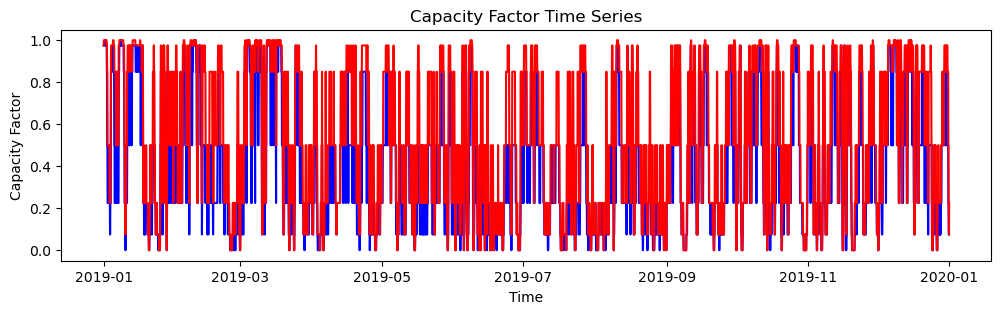

In [123]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(ws["north_sea_m_s"], color="blue")
ax.plot(ws["baltic_sea_m_s"] / 4, color="red")
ax.set_title("Capacity Factor Time Series")
ax.set_xlabel("Time")
ax.set_ylabel("Capacity Factor")
plt.show()